# Task-04: Sentiment Analysis on Social Media Data
This notebook analyzes sentiment patterns in social media text to understand public opinion.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob


Pandas is used for data handling, Matplotlib and Seaborn for visualization, and TextBlob for sentiment analysis.


In [2]:
df = pd.read_csv("twitter.csv")
df.head()


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


The dataset contains social media text along with sentiment labels for analysis.


In [4]:
df.columns


Index(['id', 'label', 'tweet'], dtype='object')

Column inspection helps identify which column contains the actual social media text.


In [7]:
# Select and rename text column safely (no warning)
if 'text' in df.columns:
    df = df[['text']].copy()
elif 'tweet' in df.columns:
    df = df[['tweet']].copy()
    df = df.rename(columns={'tweet': 'text'})

df.head()




,text
0,@user when a father is dysfunctional and is s...
1,@user @user thanks for #lyft credit i can't us...
2,bihday your majesty
3,#model i love u take with u all the time in ...
4,factsguide: society now #motivation


Only the text column is retained to simplify sentiment analysis.


In [8]:
positive_words = ['good', 'great', 'happy', 'love', 'excellent', 'best']
negative_words = ['bad', 'sad', 'hate', 'worst', 'terrible', 'poor']

def simple_sentiment(text):
    text = str(text).lower()
    pos = sum(word in text for word in positive_words)
    neg = sum(word in text for word in negative_words)
    
    if pos > neg:
        return "Positive"
    elif neg > pos:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['text'].apply(simple_sentiment)
df.head()


,text,sentiment
0,@user when a father is dysfunctional and is s...,Neutral
1,@user @user thanks for #lyft credit i can't us...,Neutral
2,bihday your majesty,Neutral
3,#model i love u take with u all the time in ...,Positive
4,factsguide: society now #motivation,Neutral


A simple rule-based approach is used to classify text as positive, negative, or neutral based on keyword presence.


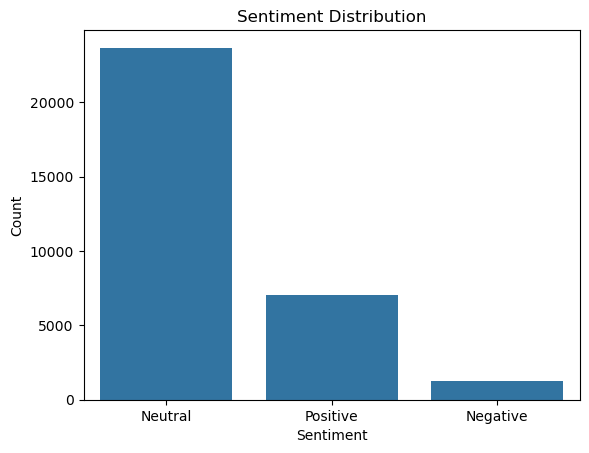

In [9]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


This plot shows the overall distribution of sentiment categories in social media data.


In [10]:
df['sentiment'].value_counts(normalize=True) * 100


sentiment
Neutral     74.037920
Positive    22.091859
Negative     3.870221
Name: proportion, dtype: float64

Sentiment percentages provide a clearer understanding of public opinion trends.


**Conclusion:** Sentiment analysis of social media text reveals clear positive, negative, and neutral opinion patterns, helping to understand public attitudes.
